In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка таблиц и знакомство с данными

In [2]:
orders = pd.read_csv('C:/Users/lyuba/Desktop/Datasets/task_2_data/orders.csv')
orders

,order_id,created_at,put_at,closed_at,issued_sum
0,400001732,2022-06-02 00:00:23.997,2022-06-02 20:18:00.180,2022-10-17 11:52:22.190,13600.0
1,400005838,2022-06-02 00:10:22.997,2022-06-02 15:41:33.267,2022-06-02 17:38:43.917,20000.0
2,400007915,2022-06-02 00:18:04.000,2022-06-05 19:17:38.547,2022-06-21 21:55:51.877,5820.0
3,400008952,2022-06-02 00:22:07.000,2022-06-03 14:25:18.033,2022-07-12 10:47:46.307,9000.0
4,400009027,2022-06-02 00:25:39.000,2022-06-02 00:40:40.320,2022-06-22 14:15:07.423,5000.0
...,...,...,...,...,...
55743,495174013,2022-08-31 23:29:32.000,2022-09-01 00:07:26.307,NaN,9500.0
55744,495174505,2022-08-31 23:41:57.997,2022-09-05 17:51:19.003,2022-09-16 18:36:09.857,14930.0
55745,495175322,2022-08-31 23:46:04.997,2022-09-01 00:03:52.010,2022-09-09 21:08:18.970,4000.0
55746,495176080,2022-08-31 23:47:20.997,2022-08-31 23:49:03.027,2022-09-12 00:58:57.037,5000.0


In [3]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55748 entries, 0 to 55747
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    55748 non-null  int64  
 1   created_at  55748 non-null  object 
 2   put_at      55748 non-null  object 
 3   closed_at   46472 non-null  object 
 4   issued_sum  55748 non-null  float64
dtypes: float64(1), int64(1), object(3)
memory usage: 2.1+ MB


In [4]:
payments = pd.read_csv('C:/Users/lyuba/Desktop/Datasets/task_2_data/payments.csv')
payments

,order_id,paid_at,paid_sum
0,400013633,2022-06-02 00:48:13.800,2500.00
1,400018480,2022-06-02 01:52:05.707,1070.00
2,400032001,2022-06-02 04:55:40.307,4200.00
3,400033195,2022-06-02 05:44:23.480,2850.00
4,400039407,2022-06-02 06:53:54.503,10100.00
...,...,...,...
143279,469255350,2022-12-08 12:57:23.747,343.99
143280,452985418,2022-12-08 12:59:40.997,984.83
143281,490824962,2022-12-08 13:09:21.673,866.04
143282,480026135,2022-12-08 13:25:11.987,1193.25


In [5]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143284 entries, 0 to 143283
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   order_id  143284 non-null  int64  
 1   paid_at   143284 non-null  object 
 2   paid_sum  143284 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 3.3+ MB


In [6]:
plan = pd.read_csv('C:/Users/lyuba/Desktop/Datasets/task_2_data/plan.csv')
plan

,order_id,plan_at,plan_sum_total
0,400001732,2022-06-02,5600.00
1,400001732,2022-07-02,9450.00
2,400001732,2022-08-01,12170.00
3,400001732,2022-08-31,14890.00
4,400001732,2022-09-30,17610.00
...,...,...,...
420277,495177509,2022-12-22,34248.70
420278,495177509,2023-01-06,36863.04
420279,495177509,2023-01-21,39440.38
420280,495177509,2023-02-05,41980.73


In [7]:
plan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420282 entries, 0 to 420281
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   order_id        420282 non-null  int64  
 1   plan_at         420282 non-null  object 
 2   plan_sum_total  420282 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 9.6+ MB


### Проверка распределения и выбросов

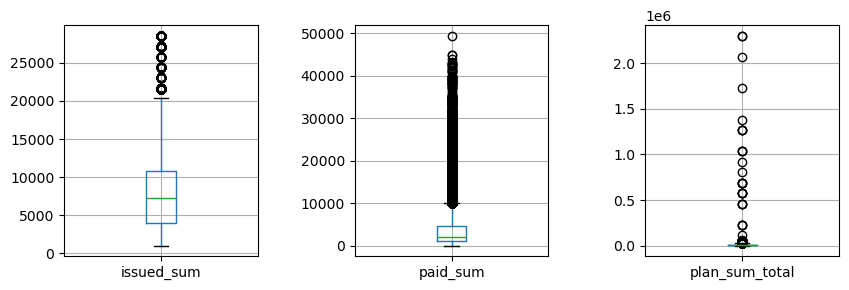

In [8]:
fig, ax = plt.subplots(1,3, figsize=(10,3))

orders.boxplot(column='issued_sum', ax=ax[0])
payments.boxplot(column='paid_sum', ax=ax[1])
plan.boxplot(column='plan_sum_total', ax=ax[2])

plt.subplots_adjust(wspace=0.5)

## Общий анализ задолженностей

In [9]:
# добавляем к каждому кредиту дату планируемого закрытия и итоговую сумму выплат с процентами
status = orders.merge(plan.groupby('order_id').max(), on='order_id', how='inner').rename({'plan_at': 'closed_plan'}, axis=1) 
# колонка plan_sum_total - общая итоговая сумма платежа по кредиту (плановая)

# добавляем к каждому кредиту фактическую сумму выплат на 08/12/2022
status = status.merge(payments.groupby('order_id', as_index=False)['paid_sum'].sum(), on='order_id', how='left').rename({'paid_sum': 'paid_sum_total'}, axis=1)

# заполним пустые значения в столбце paid_sum_total на 0
status['paid_sum_total'] = status['paid_sum_total'].fillna(0)

# нормализуем даты, убрав из них время, чтобы отклонение по часам (в течение суток) не учитывалось
status['created_at'] = pd.to_datetime(status['created_at']).dt.normalize()
status['put_at'] = pd.to_datetime(status['put_at']).dt.normalize()
status['closed_at'] = pd.to_datetime(status['closed_at']).dt.normalize()

# добавляем статус закрытия к каждому кредиту на 08/12/2022
status = status.assign(closed_stat = lambda x: 
              np.select([status['closed_at'] < status['closed_plan'], 
                        status['closed_at']== status['closed_plan'],
                        status['closed_at'] > status['closed_plan'],
                        status['closed_plan'] > '2022-12-08'], 
                        ['Досрочно', 'В срок', 'Просрочено, закрыто', 'Не просрочено, не закрыто'], 'Просрочено, не закрыто'))

status

,order_id,created_at,put_at,closed_at,issued_sum,closed_plan,plan_sum_total,paid_sum_total,closed_stat
0,400001732,2022-06-02,2022-06-02,2022-10-17,13600.0,2022-11-29,23050.00,23050.00,Досрочно
1,400005838,2022-06-02,2022-06-02,2022-06-02,20000.0,2022-06-17,23000.00,20200.00,Досрочно
2,400007915,2022-06-02,2022-06-05,2022-06-21,5820.0,2022-12-02,8579.10,8579.10,Досрочно
3,400008952,2022-06-02,2022-06-03,2022-07-12,9000.0,2022-06-18,12628.36,12628.36,"Просрочено, закрыто"
4,400009027,2022-06-02,2022-06-02,2022-06-22,5000.0,2022-06-17,6013.70,6013.70,"Просрочено, закрыто"
...,...,...,...,...,...,...,...,...,...
55743,495174013,2022-08-31,2022-09-01,NaT,9500.0,2023-02-20,16553.89,2500.00,"Не просрочено, не закрыто"
55744,495174505,2022-08-31,2022-09-05,2022-09-16,14930.0,2023-02-24,21243.04,21243.04,Досрочно
55745,495175322,2022-08-31,2022-09-01,2022-09-09,4000.0,2022-09-16,4600.00,4320.00,Досрочно
55746,495176080,2022-08-31,2022-08-31,2022-09-12,5000.0,2022-09-15,5750.00,5600.00,Досрочно


### Статусы закрытия кредитов

In [10]:
status['closed_stat'].value_counts().to_frame()

,count
closed_stat,
Досрочно,41437
"Не просрочено, не закрыто",8147
"Просрочено, закрыто",2784
В срок,2251
"Просрочено, не закрыто",1129


<Axes: xlabel='count', ylabel='closed_stat'>

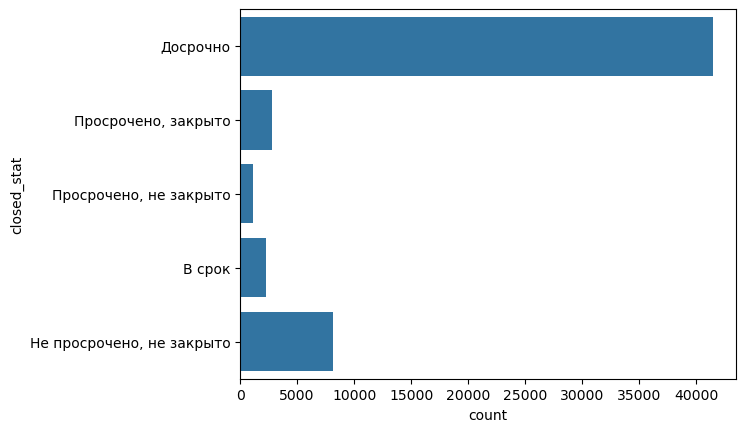

In [11]:
sns.countplot(status['closed_stat'])

### Список всех просроченных кредитов (закрытых и нет)

In [ ]:
delayed_orders = status.query('closed_stat in ["Просрочено, закрыто", "Просрочено, не закрыто"]')
delayed_orders 

,order_id,created_at,put_at,closed_at,issued_sum,closed_plan,plan_sum_total,paid_sum_total,closed_stat
3,400008952,2022-06-02,2022-06-03,2022-07-12,9000.0,2022-06-18,12628.36,12628.36,"Просрочено, закрыто"
4,400009027,2022-06-02,2022-06-02,2022-06-22,5000.0,2022-06-17,6013.70,6013.70,"Просрочено, закрыто"
19,400028637,2022-06-02,2022-06-20,2022-07-07,4000.0,2022-07-05,4684.39,4684.39,"Просрочено, закрыто"
31,400039450,2022-06-02,2022-06-02,NaT,8140.0,2022-11-21,15917.51,2140.00,"Просрочено, не закрыто"
53,400087077,2022-06-02,2022-06-02,NaT,2920.0,2022-11-29,5675.95,0.00,"Просрочено, не закрыто"
...,...,...,...,...,...,...,...,...,...
55595,494930998,2022-08-31,2022-09-05,2022-09-22,7000.0,2022-09-20,8197.68,8197.68,"Просрочено, закрыто"
55619,494974380,2022-08-31,2022-09-03,2022-09-24,6000.0,2022-09-18,7279.73,7279.73,"Просрочено, закрыто"
55643,495019341,2022-08-31,2022-09-19,2022-10-09,3000.0,2022-10-04,3608.22,3608.22,"Просрочено, закрыто"
55708,495112756,2022-08-31,2022-09-02,2022-09-20,4000.0,2022-09-17,4726.58,4726.58,"Просрочено, закрыто"


## Анализ динамики платежей

In [13]:
# суммируем платежи, совершенные за один день по одному кредиту
payments_days = payments # создаем новую таблицу
payments_days['paid_at'] = pd.to_datetime(payments_days['paid_at']).dt.normalize() # нормализуем дату, отсекая вермя
new_payments = payments_days.groupby(['order_id', 'paid_at'], as_index=False).sum() # суммируем платежи

# сортируем таблицы с фактическими и плановыми платежами по order_id и дате
new_payments = new_payments.sort_values(['order_id', 'paid_at'])
new_plan = plan.sort_values(['order_id', 'plan_at'])

# нумеруем платежи в рамках одного кредита
new_payments['payment_num'] = new_payments.groupby('order_id').cumcount() + 1
new_plan['payment_num'] = new_plan.groupby('order_id').cumcount() + 1

# соединяем таблицы по order_id и номеру платежа
payments_detailed = new_payments.merge(new_plan
                                       .rename({'plan_sum_total': 'plan_cum_sum_pbyp'}, axis=1), # колонка plan_cum_sum_pbyp - накопленная сумма плановых платежов по кредиту (payment by payment)
                                       on=['order_id', 'payment_num'], how='outer')

# высчитываем количество дней просрочки по каждому платежу
payments_detailed['delay_days'] = (payments_detailed['paid_at'] - pd.to_datetime(payments_detailed['plan_at'])).dt.days

payments_detailed['paid_sum'] = payments_detailed['paid_sum'].fillna(0)

payments_detailed

,order_id,paid_at,paid_sum,payment_num,plan_at,plan_cum_sum_pbyp,delay_days
0,400001732,2022-06-02,5600.0,1,2022-06-02,5600.00,0.0
1,400001732,2022-06-16,3850.0,2,2022-07-02,9450.00,-16.0
2,400001732,2022-07-15,2720.0,3,2022-08-01,12170.00,-17.0
3,400001732,2022-08-16,2720.0,4,2022-08-31,14890.00,-15.0
4,400001732,2022-09-15,2720.0,5,2022-09-30,17610.00,-15.0
...,...,...,...,...,...,...,...
420313,495177509,NaT,0.0,9,2022-12-22,34248.70,NaN
420314,495177509,NaT,0.0,10,2023-01-06,36863.04,NaN
420315,495177509,NaT,0.0,11,2023-01-21,39440.38,NaN
420316,495177509,NaT,0.0,12,2023-02-05,41980.73,NaN


In [14]:
# соединяем таблицу status и payments_detailed для получения таблицы с полной информацией по каждому платежу

full_info = status.merge(payments_detailed, on='order_id', how='right')       
full_info

,order_id,created_at,put_at,closed_at,issued_sum,closed_plan,plan_sum_total,paid_sum_total,closed_stat,paid_at,paid_sum,payment_num,plan_at,plan_cum_sum_pbyp,delay_days
0,400001732,2022-06-02,2022-06-02,2022-10-17,13600.0,2022-11-29,23050.00,23050.00,Досрочно,2022-06-02,5600.0,1,2022-06-02,5600.00,0.0
1,400001732,2022-06-02,2022-06-02,2022-10-17,13600.0,2022-11-29,23050.00,23050.00,Досрочно,2022-06-16,3850.0,2,2022-07-02,9450.00,-16.0
2,400001732,2022-06-02,2022-06-02,2022-10-17,13600.0,2022-11-29,23050.00,23050.00,Досрочно,2022-07-15,2720.0,3,2022-08-01,12170.00,-17.0
3,400001732,2022-06-02,2022-06-02,2022-10-17,13600.0,2022-11-29,23050.00,23050.00,Досрочно,2022-08-16,2720.0,4,2022-08-31,14890.00,-15.0
4,400001732,2022-06-02,2022-06-02,2022-10-17,13600.0,2022-11-29,23050.00,23050.00,Досрочно,2022-09-15,2720.0,5,2022-09-30,17610.00,-15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420313,495177509,2022-08-31,2022-09-01,NaT,27130.0,2023-02-20,44484.12,36863.04,"Не просрочено, не закрыто",NaT,0.0,9,2022-12-22,34248.70,NaN
420314,495177509,2022-08-31,2022-09-01,NaT,27130.0,2023-02-20,44484.12,36863.04,"Не просрочено, не закрыто",NaT,0.0,10,2023-01-06,36863.04,NaN
420315,495177509,2022-08-31,2022-09-01,NaT,27130.0,2023-02-20,44484.12,36863.04,"Не просрочено, не закрыто",NaT,0.0,11,2023-01-21,39440.38,NaN
420316,495177509,2022-08-31,2022-09-01,NaT,27130.0,2023-02-20,44484.12,36863.04,"Не просрочено, не закрыто",NaT,0.0,12,2023-02-05,41980.73,NaN


In [15]:
# добавляем статус просрочки по платежам (есть или нет)

full_info['is_delayed'] = (
    (full_info['delay_days'] > 0) |  # платеж с задержкой
    (
        full_info['paid_at'].isna() &  # платеж отсутствует
        (full_info['closed_stat'].str.startswith('Просрочено') | full_info['closed_stat'].str.startswith('Не просрочено')) & # закрытие кредита просрочено или он вовсе не выплачен
        (full_info['plan_at'] < '2022-12-08')  # планируемый платеж доджен быть совершен до 08/12/2022
    )
)

# добавим колонку с накопленной суммой фактических платежей по каждому кредиту
full_info['paid_cum_sum_pbyp'] = full_info.groupby('order_id')['paid_sum'].cumsum()

# добавим колонку с разницей между накопленной суммой по плановому платежу и фактическому
full_info['payment_diff'] = full_info['paid_cum_sum_pbyp'] - full_info['plan_cum_sum_pbyp']

# добавляем колонку со статусом платежа по соответствию размеров фактического и планового
full_info['payment_stat'] = np.select([((full_info['payment_diff'] > 0) & (full_info['plan_at'] <= "2022-12-08")), ((full_info['payment_diff'] == 0) & (full_info['plan_at'] <= "2022-12-08")), ((full_info['payment_diff'] < 0) & (full_info['plan_at'] <= "2022-12-08"))], ['Переплата', 'Соответствует плану', 'Недоплата'], pd.NA)


full_info

,order_id,created_at,put_at,closed_at,issued_sum,closed_plan,plan_sum_total,paid_sum_total,closed_stat,paid_at,paid_sum,payment_num,plan_at,plan_cum_sum_pbyp,delay_days,is_delayed,paid_cum_sum_pbyp,payment_diff,payment_stat
0,400001732,2022-06-02,2022-06-02,2022-10-17,13600.0,2022-11-29,23050.00,23050.00,Досрочно,2022-06-02,5600.0,1,2022-06-02,5600.00,0.0,False,5600.00,0.00,Соответствует плану
1,400001732,2022-06-02,2022-06-02,2022-10-17,13600.0,2022-11-29,23050.00,23050.00,Досрочно,2022-06-16,3850.0,2,2022-07-02,9450.00,-16.0,False,9450.00,0.00,Соответствует плану
2,400001732,2022-06-02,2022-06-02,2022-10-17,13600.0,2022-11-29,23050.00,23050.00,Досрочно,2022-07-15,2720.0,3,2022-08-01,12170.00,-17.0,False,12170.00,0.00,Соответствует плану
3,400001732,2022-06-02,2022-06-02,2022-10-17,13600.0,2022-11-29,23050.00,23050.00,Досрочно,2022-08-16,2720.0,4,2022-08-31,14890.00,-15.0,False,14890.00,0.00,Соответствует плану
4,400001732,2022-06-02,2022-06-02,2022-10-17,13600.0,2022-11-29,23050.00,23050.00,Досрочно,2022-09-15,2720.0,5,2022-09-30,17610.00,-15.0,False,17610.00,0.00,Соответствует плану
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420313,495177509,2022-08-31,2022-09-01,NaT,27130.0,2023-02-20,44484.12,36863.04,"Не просрочено, не закрыто",NaT,0.0,9,2022-12-22,34248.70,NaN,False,36863.04,2614.34,<NA>
420314,495177509,2022-08-31,2022-09-01,NaT,27130.0,2023-02-20,44484.12,36863.04,"Не просрочено, не закрыто",NaT,0.0,10,2023-01-06,36863.04,NaN,False,36863.04,0.00,<NA>
420315,495177509,2022-08-31,2022-09-01,NaT,27130.0,2023-02-20,44484.12,36863.04,"Не просрочено, не закрыто",NaT,0.0,11,2023-01-21,39440.38,NaN,False,36863.04,-2577.34,<NA>
420316,495177509,2022-08-31,2022-09-01,NaT,27130.0,2023-02-20,44484.12,36863.04,"Не просрочено, не закрыто",NaT,0.0,12,2023-02-05,41980.73,NaN,False,36863.04,-5117.69,<NA>


## Анализ просрочек с нарушением *времени* выплат

### Общая доля просроченных платежей

In [16]:
delay_rate = full_info['is_delayed'].mean()*100
print(f"Общая средняя доля просрочек: {(delay_rate).round(1)}%")

Общая средняя доля просрочек: 19.0%


### Доля просрочек в соответствии с месяцем выдачи кредита

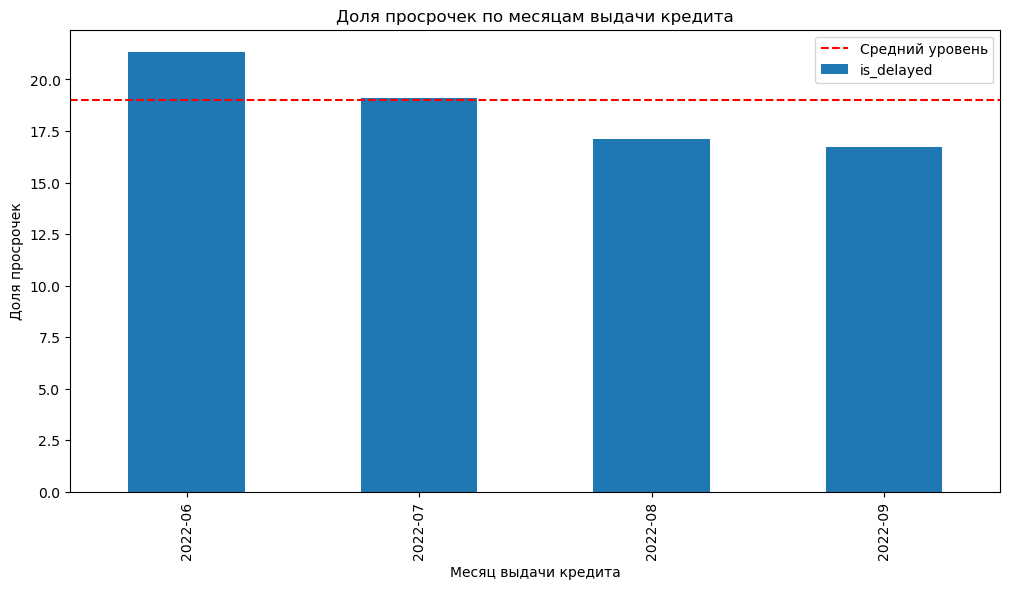

In [17]:
full_info['issue_month'] = full_info['put_at'].dt.to_period('M') # создаем новую переменную - месяц выдачи кредита 
monthly_delay = full_info.groupby('issue_month')['is_delayed'].mean()*100 # группируем данные по месяцу выдачи кредита и считаем среднее

monthly_delay.plot(kind='bar', figsize=(12, 6))
plt.title('Доля просрочек по месяцам выдачи кредита')
plt.xlabel('Месяц выдачи кредита')
plt.ylabel('Доля просрочек')
plt.axhline(delay_rate, color='red', linestyle='--', label='Средний уровень')
plt.legend()
plt.show()

### Вывод: 
1. Наблюдается снижение доли просрочек у кредитов, взятых в более поздние месяца. 
2. У кредитов, взятых в июне 2022 - неибольшая доля просрочек (более 21%), что незначительно, но превышает среднее значение просрочек по всем кредитам.
3. Кредиты, выданные в августе и сентябре имеют практически одинаковую долю просрочек (около 17%), что ниже среднего уровня.

Возможно, причина в том, что с даты взятия кредитов в сентябре прошло меньше времени, соответствено, должно было быть меньше плановых платежей, которые заемщики имели бы возможность выплатить, поэтому доля просрочек меньше.

### Доля просрочек в соответствии с очередностью платежей

!!! считаем лишь по тем платежам, которые должны быть совершены до 08-12-2022

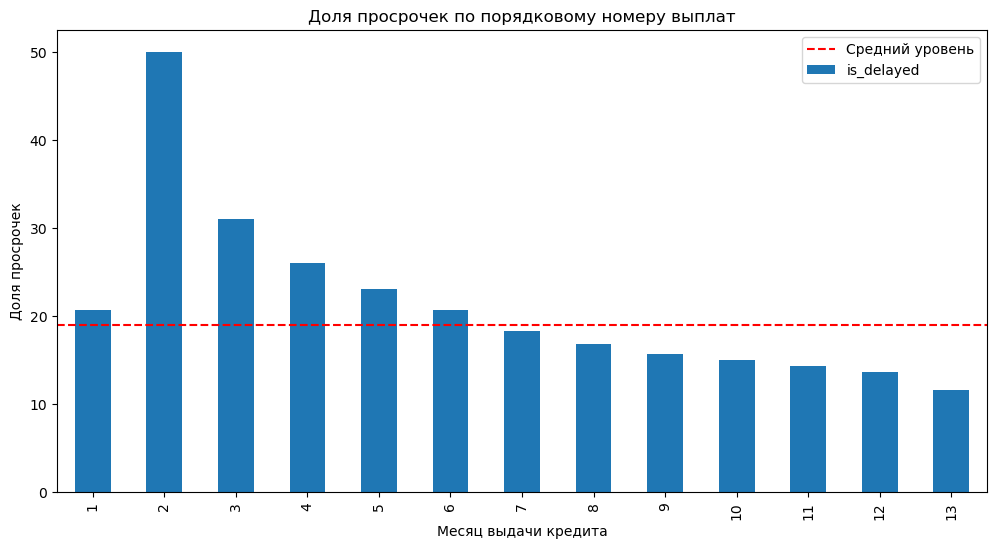

In [18]:
delay_pbyp = full_info.query('plan_at < "2022-12-08"').groupby('payment_num')['is_delayed'].mean()*100 # группируем по порядковому номеру платежа

delay_pbyp.plot(kind='bar', figsize=(12, 6))
plt.title('Доля просрочек по порядковому номеру выплат')
plt.xlabel('Месяц выдачи кредита')
plt.ylabel('Доля просрочек')
plt.axhline(delay_rate, color='red', linestyle='--', label='Средний уровень')
plt.legend()
plt.show()

### Выводы: 
1. На графике заметен явно выраженный пик с высокой долей просрочек, он приходится на второй по счету платеж. Правктически в 50% случаев (каждый второй кредит) второй платеж по кредиту не выплачивается вовремя.
2. Третий и четвертый платежи также превышают средний уровень по доле просрочки на примерно 10 и 5 процентов соответственно.

Таким образом, такая динамика противоречит предположению о том, что первые платежи выплачиваются вовремя, и причина сниженной доли просрочки у кредитов взятых в более поздние месяца не столь очевидная, и ее выяснение требует дополнительных исследований.

### Доля просрочек в соответствии с месяцем плановой выплаты

!!! считаем лишь по тем платежам, которые должны быть совершены до 08-12-2022

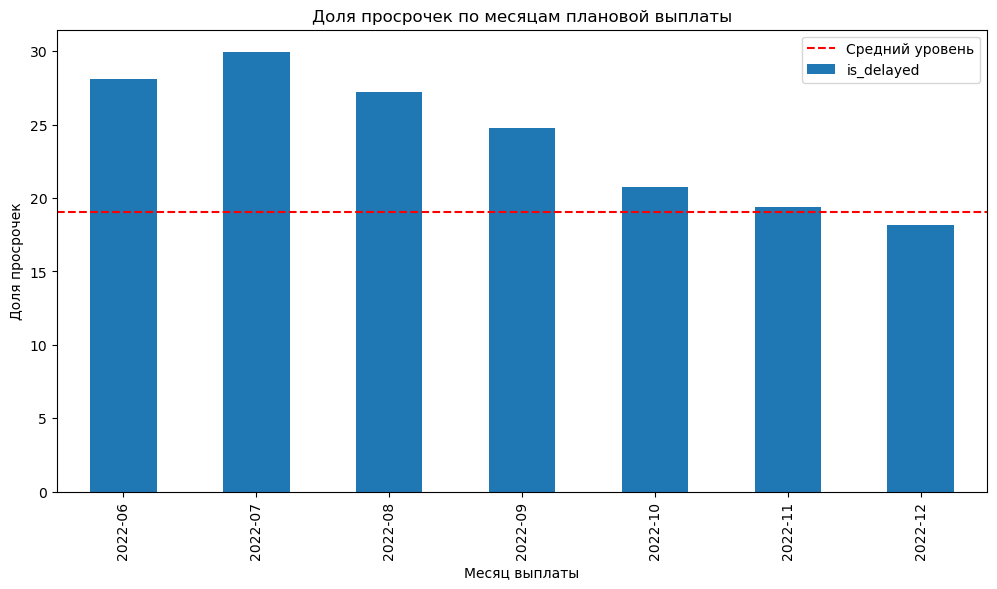

In [19]:
full_info['payment_month'] = pd.to_datetime(full_info['plan_at']).dt.to_period('M')
monthly_delay2 = full_info.query('plan_at < "2022-12-08"').groupby('payment_month')['is_delayed'].mean()*100 # группируем по месяцам плановой выплаты

monthly_delay2.plot(kind='bar', figsize=(12, 6))
plt.title('Доля просрочек по месяцам плановой выплаты')
plt.xlabel('Месяц выплаты')
plt.ylabel('Доля просрочек')
plt.axhline(delay_rate, color='red', linestyle='--', label='Средний уровень')
plt.legend()
plt.show()

### Выводы: 
1. Для платежей, которые необходимо было совершить в летние месяцы, характерна наиболее большая доля просрочки (в среднем на 15% превышающая средний уровень) с пиком в июле.
2. С июля характерно стабильное снижение доли просрочки, достигшее своего минимума в декабре.

Получается, что изначальное различие в доле просрочки по месяцам выдачи кредита может быть связано с тем, что кредиты взятые в июне-июле имели большую долю просрочки в первые месяцы платежей. В то время как кредиты, взятые в августе и сентябре изначально (в первых двух платежах) имели меньшую долю просрочки.

### Распределение просрочек в соответствии с количеством дней задержки выплаты

In [20]:
full_info.query('plan_at < "2022-12-08"').query('delay_days > 0')['delay_days'].agg({'Всего просроченных платежей': 'count',
                                                                                     'Среднее время просрочки': 'mean', 
                                                                                     'Медианное время просрочки': 'median',
                                                                                     'Максимальное время просрочки': 'max', 
                                                                                     'Количество просрочек с количеством дней < 20': lambda x: x.to_frame().query('delay_days < 20')['delay_days'].count()}).to_frame()

,delay_days
Всего просроченных платежей,38141.000000
Среднее время просрочки,18.814058
Медианное время просрочки,12.000000
Максимальное время просрочки,178.000000
Количество просрочек с количеством дней < 20,26229.000000


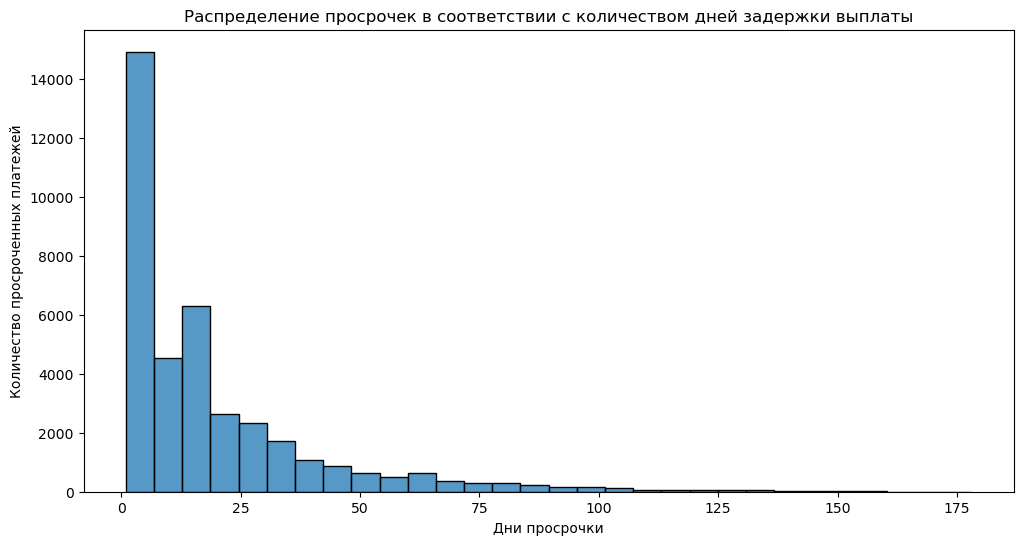

In [21]:
plt.figure(figsize=(12, 6))
sns.histplot(full_info.query('plan_at < "2022-12-08"').query('delay_days > 0')['delay_days'], bins=30)
plt.title('Распределение просрочек в соответствии с количеством дней задержки выплаты')
plt.xlabel('Дни просрочки')
plt.ylabel('Количество просроченных платежей')
plt.show()

### Выводы: 
1. Наибольшее количество просрочек не превышает 20 дней, что близко к среднему значению (19 дней). Это 26229 просрочек из 38141 (общее количество просрочек), что составляет около 68%. Однако учитывая неравномерность распределения лучше сранивать это значение с медианным временем просрочки, которое составляет 12 дней.
2. Максимальное количество дней просрочки равно 178 дням. 

### Зависимость просрочки от суммы кредита

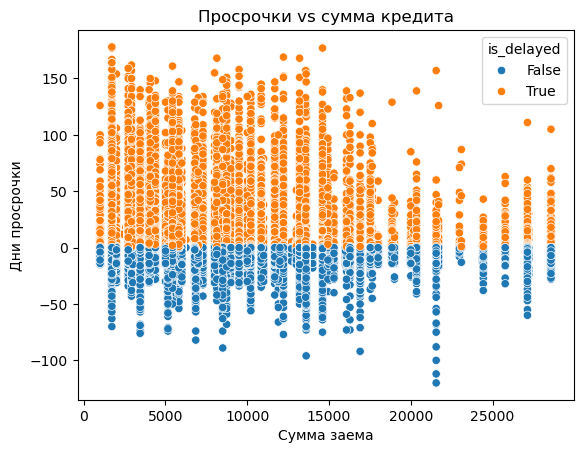

In [22]:
sns.scatterplot(data=full_info, x='issued_sum', y='delay_days', hue='is_delayed')
plt.title('Просрочки vs сумма кредита')
plt.xlabel('Сумма заема')
plt.ylabel('Дни просрочки')
plt.show()

### Вывод:
1. Наиболее часто и на наибольшее количество дней просрочки случаются при взятии кредита на сумму до 15000 руб.

## Анализ просрочек с нарушением *объема* выплат 

### Соотношение плановых и фактических платежей

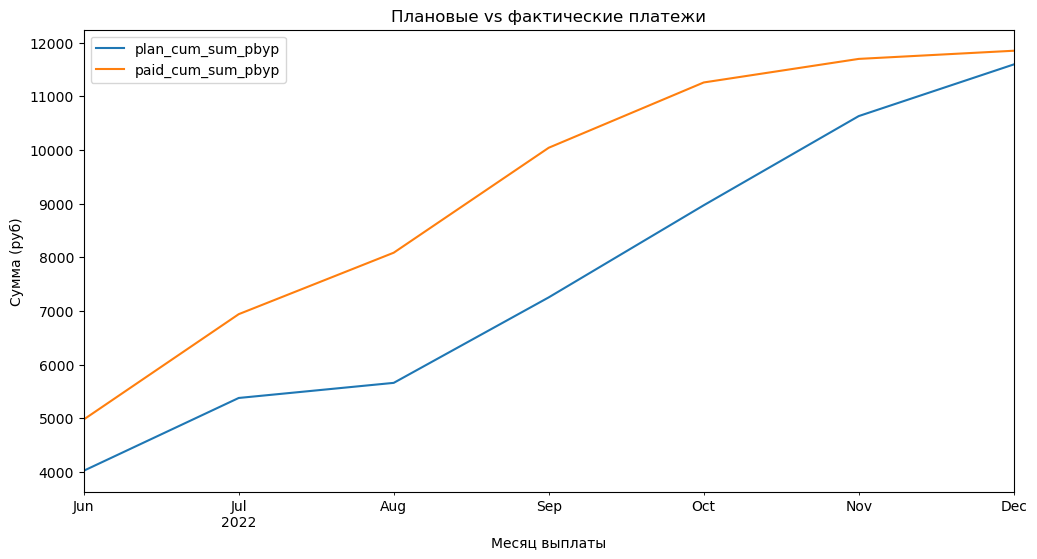

,plan_cum_sum_pbyp,paid_cum_sum_pbyp,diff
payment_month,,,
2022-06,4023.755841,4978.640774,954.884933
2022-07,5379.580432,6940.659258,1561.078826
2022-08,5660.952377,8085.702750,2424.750373
2022-09,7253.545833,10040.863833,2787.317999
2022-10,8969.358150,11257.057969,2287.699819
2022-11,10630.722366,11696.001686,1065.279320
2022-12,11592.679034,11847.902112,255.223078


In [23]:
payment_comparison = full_info.query('plan_at < "2022-12-08"').groupby('payment_month')[['plan_cum_sum_pbyp', 'paid_cum_sum_pbyp']].mean()
payment_comparison.plot(figsize=(12, 6))
plt.title('Плановые vs фактические платежи')
plt.xlabel('Месяц выплаты')
plt.ylabel('Сумма (руб)')
plt.show()
payment_comparison.assign(diff = payment_comparison['paid_cum_sum_pbyp'] - payment_comparison['plan_cum_sum_pbyp'])

### Выводы: 
1. В течение всего времени заметно превышение *фактических* сумм выплат над *плановыми*.
2. Наибольший разрыв наблюдается в сентябре (2787 руб.). Наименьший - в декабре (255 руб.)

### Отклонение платежей по месяцам

Более наглядное представление разницы между фактическими и плановыми выплатами

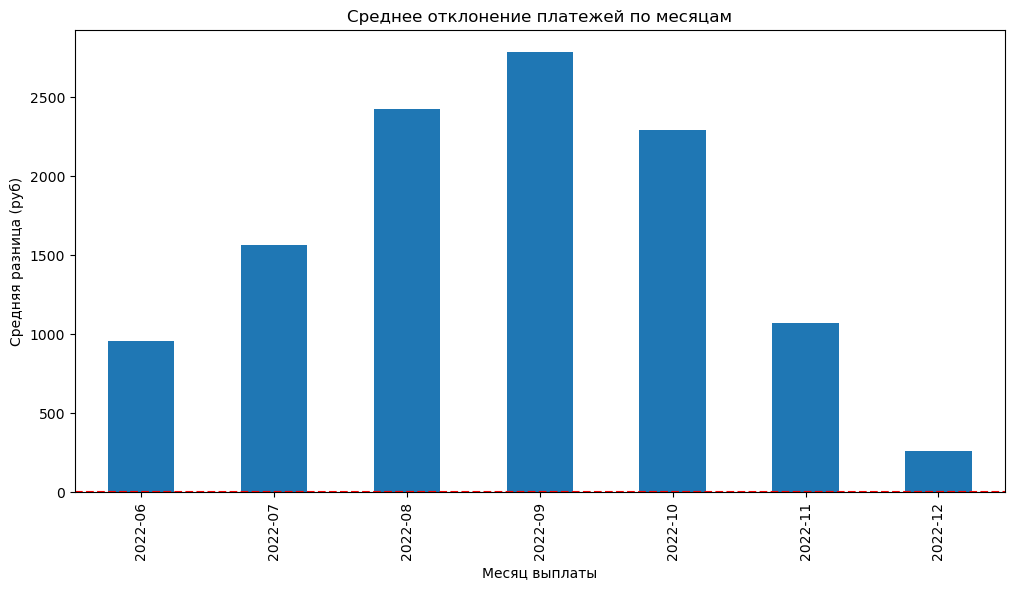

In [24]:
monthly_diff2 = full_info.query('plan_at < "2022-12-08"').groupby('payment_month')['payment_diff'].mean()

plt.figure(figsize=(12, 6))
monthly_diff2.plot(kind='bar')
plt.title('Среднее отклонение платежей по месяцам')
plt.xlabel('Месяц выплаты')
plt.ylabel('Средняя разница (руб)')
plt.axhline(0, color='red', linestyle='--')
plt.show()

### Распределение статусов платежей по соответствию размеров фактического плановому

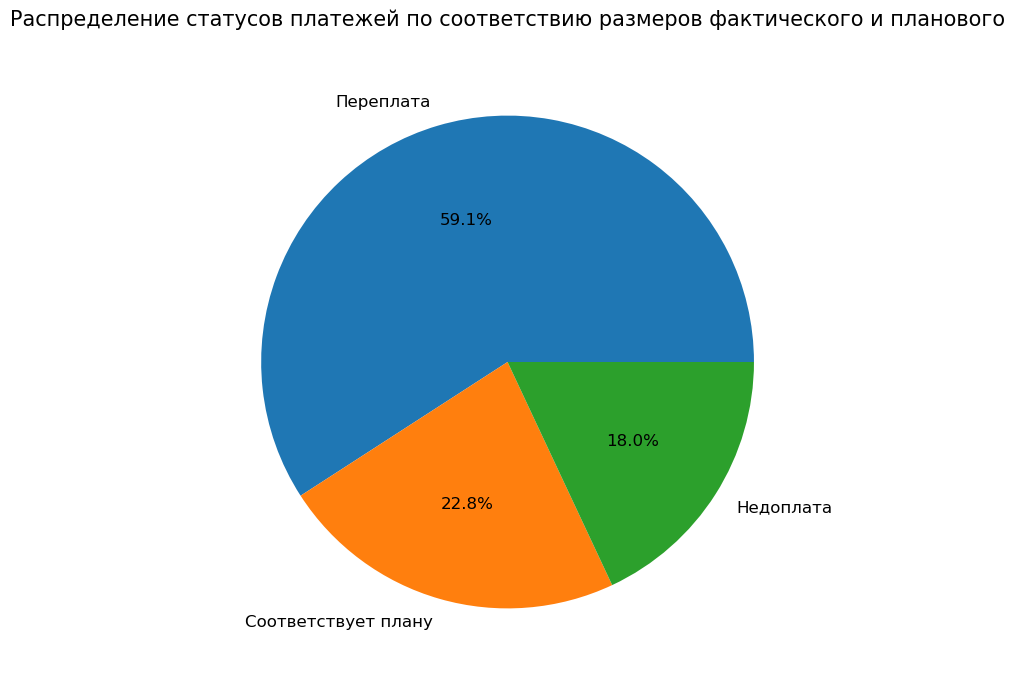

In [25]:
payment_stats = full_info['payment_stat'].value_counts(dropna=True)

plt.figure(figsize=(8, 8))
plt.pie(
    payment_stats,
    labels=payment_stats.index,
    autopct='%1.1f%%',
    textprops={'fontsize': 12}
)

plt.title('Распределение статусов платежей по соответствию размеров фактического и планового', pad=20, fontsize=15)
plt.show()

### Вывод:
59,1% всех фактических платежей превышает плановые, 22,8% соответствуют плановым и лишь 18% меньше плановых. 

### Средний размер просрочки

In [26]:
delay_rate2 = abs(full_info.query('payment_diff < 0')['payment_diff'].mean())
print(f"Средний размер просрочки: {(delay_rate2).round(1)}")

delay_sum = abs(full_info.query('payment_diff < 0')['payment_diff'].sum())
print(f"Общая сумма долга банку: {(delay_sum).round(1)}")

Средний размер просрочки: 4951.4
Общая сумма долга банку: 417382139.6


### Доля просрочек по месяцам плановой выплаты (по сумме платежа)

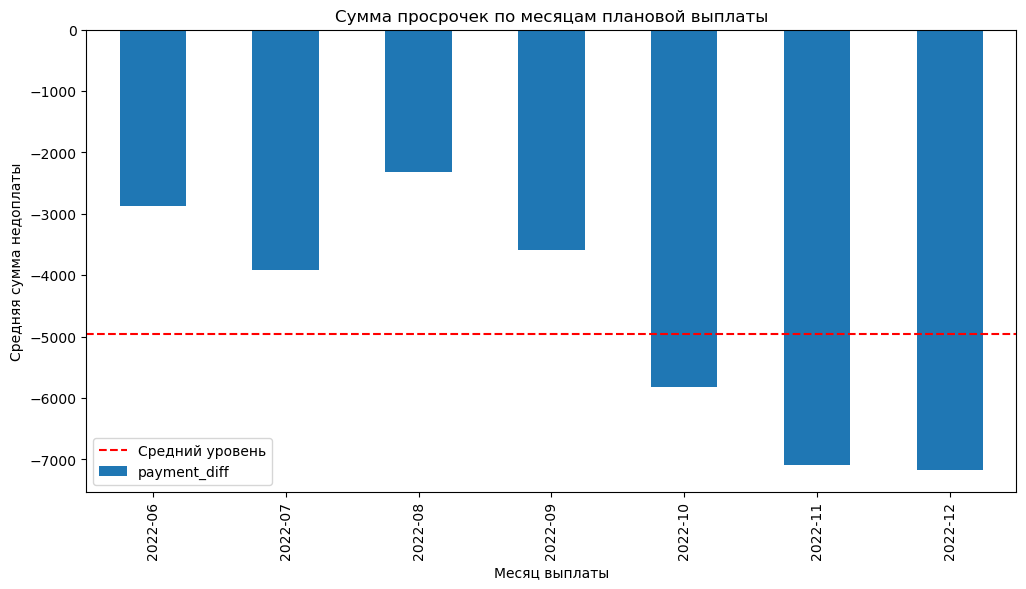

,payment_diff
payment_month,
2022-06,-2873.567752
2022-07,-3922.771592
2022-08,-2318.367181
2022-09,-3586.319125
2022-10,-5815.175662
2022-11,-7098.270398
2022-12,-7167.880356


In [31]:
monthly_delay3 = full_info.query('plan_at < "2022-12-08"').query('payment_diff < 0').groupby('payment_month')['payment_diff'].mean() # группируем по месяцам плановой выплаты

monthly_delay3.plot(kind='bar', figsize=(12, 6))
plt.title('Сумма просрочек по месяцам плановой выплаты')
plt.xlabel('Месяц выплаты')
plt.ylabel('Средняя сумма недоплаты')
plt.axhline(delay_rate2*(-1), color='red', linestyle='--', label='Средний уровень')
plt.legend()
plt.show()

monthly_delay3.to_frame()

### Выводы: 
1. Динамика недоплат носит волнообразный характер с пиками в июле и в декабре и резким увеличением недоплат в октябре.
2. Наибольшая общая сумма недоплаты по всем кредитам наблюдается в ноябре и декабре (7000 руб.). Наименьшая в августе (2300 руб.).
3. С октября общая сумма недоплат превышает средний уровень.

### Сумма просрочек по порядковому номеру выплат

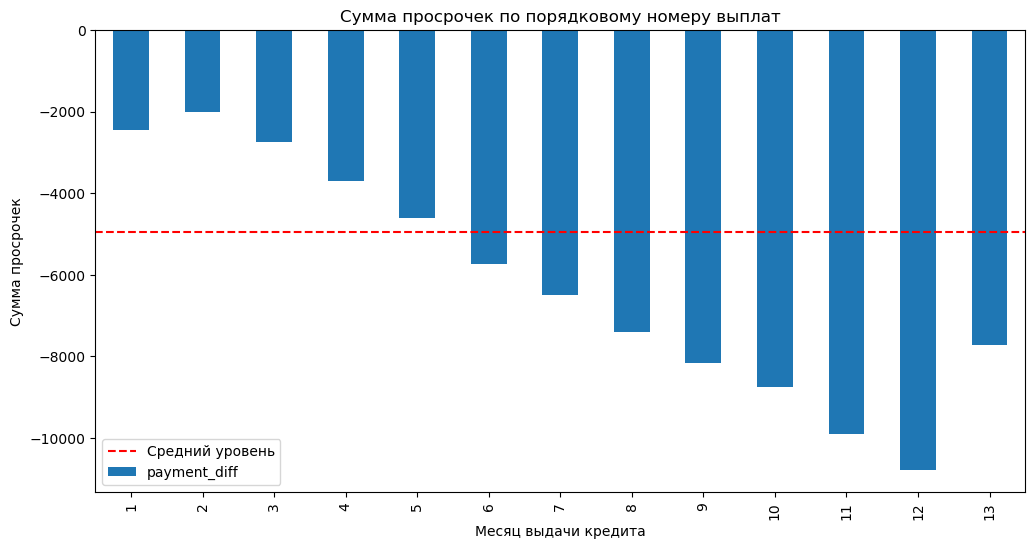

In [32]:
delay_pbyp2 = full_info.query('plan_at < "2022-12-08"').query('payment_diff < 0').groupby('payment_num')['payment_diff'].mean() # группируем по порядковому номеру платежа

delay_pbyp2.plot(kind='bar', figsize=(12, 6))
plt.title('Сумма просрочек по порядковому номеру выплат')
plt.xlabel('Месяц выдачи кредита')
plt.ylabel('Сумма просрочек')
plt.axhline(delay_rate2*(-1), color='red', linestyle='--', label='Средний уровень')
plt.legend()
plt.show()

### Выводы: 
1. С увеличением порядкового номера платежа общая сумма просрочек стабильно увеличивается за исключением второгои тринадцатого платежа, для которых характерно, напротив, снижение.
2. В первые пять платежей общая сумма просрочки ниже среднего уровня, с шестого платежа сумма начинает превышать этот уровень.

## Анализ по клиентам

### Топ-10 клиентов с наибольшими просрочками по времени 

In [33]:
top_delayed = full_info.query('is_delayed').groupby('order_id')['delay_days'].max().sort_values(ascending=False).head(10)
top_delayed.to_frame()

,delay_days
order_id,
409130210,178.0
403507749,177.0
406521074,177.0
414483815,169.0
420584751,168.0
420801925,168.0
414398328,167.0
421556699,164.0
415786034,164.0


### Топ-10 клиентов с наибольшими просрочками по общей сумме недоплат

In [34]:
top_delayed2 = full_info.query('payment_diff < 0').groupby('order_id')['payment_diff'].min().sort_values(ascending=True).head(10)
top_delayed2.to_frame()

,payment_diff
order_id,
429430737,-2279800.0
428503438,-2279800.0
414502017,-2049480.0
415298088,-1707900.0
423601955,-1367280.0
415749248,-1252460.0
415339162,-1252460.0
414262167,-1252350.0
429696967,-1025910.0


### Выводы:
1. Наибольшая просрочка по дням составляет 178 дней, по сумме просрочки 2279800 руб.
2. Интересно, что в двух этих топах нет одинакового ID кредита, то есть самые большие временные просрочки НЕ соответтсвуют самым большим просрочкам по сумме недоплат.

## Краткие выводы

С течением времени количество просрочек по времени выплат (задержке) снижается, в то время как общая сумма просрочек увеличивается. То есть клиенты с течением времени чаще платят вовремя, но сумма выплаты не соответствует плановой. 

Общая сумма долга банку: 417 382 139 руб. 

Средний размер просрочки: 4951 руб.

Общая средняя доля просрочек: 19.0%

При этом досрочно закрыто 41437 кредитов; в срок закрыто - 2251; не просрочено, не закрыто	- 8147; просрочено, закрыто - 2784; просрочено, не закрыто - 1129.
